In [16]:
# Cargar el archivo maestro crudo desde el catálogo de Kedro
df = catalog.load("nhanes_merged_data")

# Ver el tamaño real de tu dataset (Filas, Columnas)
print(f"📊 Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# Mostrar las primeras 5 filas
df.head()

[06/18/26 18:46:40] INFO     Loading data from nhanes_merged_data (ParquetDataset)...          ]8;id=4230082;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=4230083;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

📊 Dimensiones del dataset: 15456 filas y 141 columnas.



,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,SMQ930,SMQ935,SMQ080,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,SMAQUEX2
0,83732,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,2.0,NaN,2.0,NaN,1.0,5.397605e-79,1.0
1,83733,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,1.0,3.000000e+01,2.0,NaN,2.0,NaN,1.0
2,83734,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,1.0,5.397605e-79,2.0,NaN,1.0,5.397605e-79,1.0
3,83735,9.0,2.0,2.0,56.0,NaN,3.0,3.0,2.0,NaN,...,7.0,3.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0
4,83736,9.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,1.0,7.000000e+00,2.0,NaN,2.0,NaN,1.0


In [17]:
# 1. Definir nuestras columnas de interés clínico
columnas_clave = [
    'SEQN',      # ID del participante
    'RIAGENDR',  # Sexo (1: Masculino, 2: Femenino)
    'RIDAGEYR',  # Edad
    'BMXWT',     # Peso (kg)
    'BMXHT',     # Estatura (cm)
    'BPXSY1',    # Presión Sistólica
    'BPXDI1',    # Presión Diastólica
    'LBXTC',     # Colesterol Total
    'SMQ020'     # ¿Ha fumado al menos 100 cigarrillos? (1: Sí, 2: No)
]

# 2. Crear un sub-dataframe solo con estas columnas
df_analisis = df[columnas_clave].copy()

# 3. Mostrar la cantidad de nulos por columna
print(" VALORES NULOS EN NUESTRAS COLUMNAS CLAVE:")
print(df_analisis.isnull().sum())

# 4. Mostrar estadísticas rápidas para detectar códigos de error (Mínimos y Máximos)
print("\n📊 RESUMEN ESTADÍSTICO INICIAL:")
df_analisis.describe()

 VALORES NULOS EN NUESTRAS COLUMNAS CLAVE:
SEQN           0
RIAGENDR       0
RIDAGEYR       0
BMXWT        191
BMXHT        188
BPXSY1      2009
BPXDI1      2009
LBXTC       1462
SMQ020      4188
dtype: int64

📊 RESUMEN ESTADÍSTICO INICIAL:


,SEQN,RIAGENDR,RIDAGEYR,BMXWT,BMXHT,BPXSY1,BPXDI1,LBXTC,SMQ020
count,15456.000000,15456.000000,15456.000000,15265.000000,15268.000000,13447.000000,1.344700e+04,13994.000000,11268.000000
mean,93347.525233,1.512746,38.696493,72.788614,161.185499,120.910389,6.696155e+01,180.082321,1.601970
std,5535.513649,0.499854,23.138561,26.796892,15.308451,19.270442,1.531663e+01,40.983846,0.533583
min,83732.000000,1.000000,6.000000,15.500000,105.100000,72.000000,5.397605e-79,76.000000,1.000000
25%,88566.750000,1.000000,16.000000,56.100000,154.300000,108.000000,5.800000e+01,150.000000,1.000000
50%,93348.500000,2.000000,37.000000,71.700000,163.100000,118.000000,6.800000e+01,176.000000,2.000000
75%,98144.250000,2.000000,59.000000,88.200000,171.600000,130.000000,7.600000e+01,204.000000,2.000000
max,102956.000000,2.000000,80.000000,242.600000,202.700000,236.000000,1.360000e+02,545.000000,9.000000


In [18]:
import pandas as pd

# 1. Cargar el dataset maestro actualizado a través de Kedro
# (Asegúrate de que 'catalog' esté disponible, si no, usa tu método de lectura habitual)
df_master = catalog.load("nhanes_merged_data")

print("==========================================================")
print(f"📊 ¡DATASET CONSOLIDADO LISTO! Dimensión actual: {df_master.shape[0]} filas y {df_master.shape[1]} columnas")
print("==========================================================\n")

# 2. Resumen rápido de tipos de datos y nulos por columna
print("🔍 REVISIÓN DE DICTAMEN POR VARIABLE:")
info_df = pd.DataFrame({
    'Tipo de Dato': df_master.dtypes,
    'Registros Válidos': df_master.count(),
    'Valores Nulos (NaN)': df_master.isnull().sum(),
    '% de Nulos': (df_master.isnull().sum() / len(df_master) * 100).round(2)
})
print(info_df.to_string())

print("\n----------------------------------------------------------")

# 3. El termómetro del filtro: ¿Cuántos adultos vs menores tenemos ahora?
adultos = (df_master['RIDAGEYR'] >= 18).sum()
menores = (df_master['RIDAGEYR'] < 18).sum()

print(f"👴 Adultos (>= 18 años): {adultos} pacientes")
print(f"👶 Menores (< 18 años): {menores} pacientes")

                    INFO     Loading data from nhanes_merged_data (ParquetDataset)...          ]8;id=4230088;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=4230089;file://C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

📊 ¡DATASET CONSOLIDADO LISTO! Dimensión actual: 15456 filas y 141 columnas

🔍 REVISIÓN DE DICTAMEN POR VARIABLE:
         Tipo de Dato  Registros Válidos  Valores Nulos (NaN)  % de Nulos
SEQN            int64              15456                    0        0.00
SDDSRVYR      float64              15456                    0        0.00
RIDSTATR      float64              15456                    0        0.00
RIAGENDR      float64              15456                    0        0.00
RIDAGEYR      float64              15456                    0        0.00
RIDAGEMN      float64                  0                15456      100.00
RIDRETH1      float64              15456                    0        0.00
RIDRETH3      float64              15456                    0        0.00
RIDEXMON      float64              15456                    0        0.00
RIDEXAGM      float64               4701                10755       69.58
DMQMILIZ      float64              11564                 3892       25.18

## Fase 1: Filtrado de la Población Objetivo (Adultos)

In [19]:
# 1. Crear una copia del dataset filtrando solo adultos
df_adultos = df_master[df_master['RIDAGEYR'] >= 18].copy()

# 2. Verificar el nuevo tamaño
print(f" Filtro aplicado. El nuevo dataset tiene {df_adultos.shape[0]} filas y {df_adultos.shape[1]} columnas.")

# 3. Comprobar que los nulos sistemáticos por edad (ej. Tabaquismo) desaparecieron o bajaron drásticamente
nulos_tabaco = df_adultos['SMQ020'].isnull().sum()
print(f"🚭 Valores nulos en la pregunta de tabaquismo (SMQ020) tras el filtro: {nulos_tabaco}")

 Filtro aplicado. El nuevo dataset tiene 11268 filas y 141 columnas.
🚭 Valores nulos en la pregunta de tabaquismo (SMQ020) tras el filtro: 0


## Fase 2: Selección de Variables Críticas (Feature Selection)

In [20]:
import pandas as pd

# 1. Calcular el diagnóstico de nulos para las 141 columnas de adultos
analisis_columnas = pd.DataFrame({
    'Nulos': df_adultos.isnull().sum(),
    '% Nulos': (df_adultos.isnull().sum() / len(df_adultos) * 100).round(2),
    'Tipo': df_adultos.dtypes
}).sort_values('% Nulos')

# 2. Vamos a agruparlas por gravedad de nulos para que las revises con calma
print("🟢 VARIABLES COMPLETAS (0% Nulos) - Ideal para usar directamente:")
print(analisis_columnas[analisis_columnas['% Nulos'] == 0].index.tolist())

print("\n🟡 VARIABLES CON POCOS NULOS (0.1% a 15% Nulos) - Excelentes candidatas para imputar:")
print(analisis_columnas[(analisis_columnas['% Nulos'] > 0) & (analisis_columnas['% Nulos'] <= 15)].to_string())

print("\n🟠 VARIABLES CON NULOS MODERADOS (15% a 40% Nulos) - Requieren evaluación:")
print(analisis_columnas[(analisis_columnas['% Nulos'] > 15) & (analisis_columnas['% Nulos'] <= 40)].to_string())

print("\n🔴 VARIABLES CON ALTO PORCENTAJE (> 40% Nulos) - ¿Tienen justificación médica o estructural?:")
print(analisis_columnas[analisis_columnas['% Nulos'] > 40].to_string())

🟢 VARIABLES COMPLETAS (0% Nulos) - Ideal para usar directamente:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMQMILIZ', 'DMDHHSIZ', 'DMDHHSZA', 'DMDFMSIZ', 'SIAINTRP', 'SIAPROXY', 'SIALANG', 'BMDSTATS', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA', 'WTINT2YR', 'DMDHRGND', 'DMDHHSZE', 'DMDHHSZB', 'SMD100BR', 'SMQ020', 'SMDUPCA', 'SMQ890', 'SMQ900', 'SMQ910', 'SMAQUEX2']

🟡 VARIABLES CON POCOS NULOS (0.1% a 15% Nulos) - Excelentes candidatas para imputar:
          Nulos  % Nulos     Tipo
DMDCITZN      4     0.04  float64
BMXHT       151     1.34  float64
BMXWT       158     1.40  float64
BMXBMI      172     1.53  float64
BPAARM      347     3.08  float64
BPACSZ      361     3.20  float64
BPXPLS      420     3.73  float64
BPXPTY      420     3.73  float64
BPXPULS     420     3.73  float64
BPXML1      433     3.84  float64
INDFMIN2    448     3.98  float64
FIAPROXY    448     3.98  float64
FIAINTRP    448     3.98  float64
FIALANG     448

In [21]:
# ## Fase 2: Selección de Variables Críticas (Feature Selection)

# Selección Manual de Variables Críticas para el Modelo de Salud
variables_clave = [
    "SEQN",       # ID único del paciente
    "RIAGENDR",   # Género (1=Masculino, 2=Femenino)
    "RIDAGEYR",   # Edad (Años)
    "RIDRETH3",   # Raza / Etnia
    "DMDEDUC2",   # Nivel educativo (Adultos)
    "DMDMARTL",   # Estado civil
    "INDFMPIR",   # Ratio de ingresos sobre nivel de pobreza
    "BMXWT",      # Peso (kg)
    "BMXHT",      # Estatura (cm)
    "BMXBMI",     # Índice de Masa Corporal (IMC)
    "BMXWAIST",   # Circunferencia de la cintura (cm)
    "BPXSY1",     # Presión Sistólica - Lectura 1
    "BPXSY2",     # Presión Sistólica - Lectura 2
    "BPXSY3",     # Presión Sistólica - Lectura 3
    "BPXDI1",     # Presión Diastólica - Lectura 1
    "BPXDI2",     # Presión Diastólica - Lectura 2
    "BPXDI3",     # Presión Diastólica - Lectura 3
    "LBXTC",      # Colesterol Total (mg/dL)
    "SMQ020"      # ¿Ha fumado al menos 100 cigarrillos en su vida? (1=Sí, 2=No)
]

# Creamos nuestro dataset de trabajo final con este subset
df_salud = df_adultos[variables_clave].copy()

print(f"🎯 Dataset de salud final estructurado: {df_salud.shape[0]} filas y {df_salud.shape[1]} variables clave.")

print("\n👀 Conteo y Porcentaje de Nulos en nuestro dataset final (df_salud):")
nulos_finales = pd.DataFrame({
    'Nulos': df_salud.isnull().sum(),
    '% Nulos': (df_salud.isnull().sum() / len(df_salud) * 100).round(2)
}).sort_values('% Nulos', ascending=False)
print(nulos_finales[nulos_finales['Nulos'] > 0])

🎯 Dataset de salud final estructurado: 11268 filas y 19 variables clave.

👀 Conteo y Porcentaje de Nulos en nuestro dataset final (df_salud):
          Nulos  % Nulos
INDFMPIR   1335    11.85
BPXSY1      968     8.59
BPXDI1      968     8.59
BMXWAIST    716     6.35
LBXTC       698     6.19
BPXDI3      644     5.72
BPXSY3      644     5.72
BPXDI2      605     5.37
BPXSY2      605     5.37
DMDEDUC2    529     4.69
DMDMARTL    529     4.69
BMXBMI      172     1.53
BMXWT       158     1.40
BMXHT       151     1.34


## Fase 3: Tratamiento de Valores Nulos e Imputación

In [22]:
# ## Fase 3.1: Filtro Físico Base (Limpieza de Nulos Críticos)

print(f"Dimensión inicial: {df_salud.shape[0]} pacientes")

# 1. Eliminar pacientes sin Peso o sin Estatura
df_salud = df_salud.dropna(subset=['BMXWT', 'BMXHT']).copy()

print(f"✅ Pacientes conservados tras eliminar nulos de Peso y Estatura: {df_salud.shape[0]}")

# 2. Recalcular y mostrar los nulos restantes
nulos_actualizados = pd.DataFrame({
    'Nulos': df_salud.isnull().sum(),
    '% Nulos': (df_salud.isnull().sum() / len(df_salud) * 100).round(2)
}).sort_values('% Nulos', ascending=False)

print("\n Nuevo panorama de nulos tras el primer filtro:")
print(nulos_actualizados[nulos_actualizados['Nulos'] > 0])

Dimensión inicial: 11268 pacientes
✅ Pacientes conservados tras eliminar nulos de Peso y Estatura: 11096

 Nuevo panorama de nulos tras el primer filtro:
          Nulos  % Nulos
INDFMPIR   1311    11.82
BPXSY1      916     8.26
BPXDI1      916     8.26
LBXTC       669     6.03
BPXSY3      598     5.39
BPXDI3      598     5.39
BMXWAIST    562     5.06
BPXDI2      560     5.05
BPXSY2      560     5.05
DMDEDUC2    515     4.64
DMDMARTL    515     4.64


Si comparamos la lista anterior con esta nueva, pasaron tres cosas:

- Desapareció el IMC (BMXBMI)! Antes tenía 172 nulos. Al borrar a las personas sin peso ni estatura, automáticamente nos deshicimos de los nulos del Índice de Masa Corporal, porque el sistema usa el peso y la altura para calcularlo. Si tienes los dos primeros, tienes el tercero.

- Cayeron los nulos de la Cintura (BMXWAIST): Pasó de 716 nulos a 562.

- Cayeron los nulos de TODO lo demás: Las presiones, el colesterol y los ingresos bajaron sus números de nulos.

## Fase 3.2: Filtro Estricto de Presión e Imputación Final

In [23]:
# 1. Filtro estricto de Presión Arterial (Al menos 2 tomas válidas)
df_salud['TOMAS_SISTOLICA'] = df_salud[['BPXSY1', 'BPXSY2', 'BPXSY3']].notnull().sum(axis=1)
df_salud['TOMAS_DIASTOLICA'] = df_salud[['BPXDI1', 'BPXDI2', 'BPXDI3']].notnull().sum(axis=1)

df_salud = df_salud[
    (df_salud['TOMAS_SISTOLICA'] >= 2) & 
    (df_salud['TOMAS_DIASTOLICA'] >= 2)
].copy()

# 2. Promediar Presión (Transformar 6 columnas en 2 limpias)
df_salud['BPXSY_MEAN'] = df_salud[['BPXSY1', 'BPXSY2', 'BPXSY3']].mean(axis=1).round(2)
df_salud['BPXDI_MEAN'] = df_salud[['BPXDI1', 'BPXDI2', 'BPXDI3']].mean(axis=1).round(2)

# Limpiar basura temporal
df_salud = df_salud.drop(columns=[
    'BPXSY1', 'BPXSY2', 'BPXSY3', 'BPXDI1', 'BPXDI2', 'BPXDI3', 
    'TOMAS_SISTOLICA', 'TOMAS_DIASTOLICA'
])

# 3. Imputación de Variables Continuas (Mediana)
vars_continuas = ['INDFMPIR', 'BMXWAIST', 'LBXTC']
for col in vars_continuas:
    mediana_val = df_salud[col].median()
    df_salud[col] = df_salud[col].fillna(mediana_val)

# 4. Imputación de Variables Categóricas (Moda)
vars_categoricas = ['DMDEDUC2', 'DMDMARTL']
for col in vars_categoricas:
    moda_val = df_salud[col].mode()[0]
    df_salud[col] = df_salud[col].fillna(moda_val)

# 5. Verificación Final
print(f" ¡Limpieza Total Completada!")
print(f"Pacientes finales listos para análisis: {df_salud.shape[0]}")
print(f"Variables finales: {df_salud.shape[1]}")
print("\n Conteo de nulos restantes:")
print(df_salud.isnull().sum())

 ¡Limpieza Total Completada!
Pacientes finales listos para análisis: 10601
Variables finales: 15

 Conteo de nulos restantes:
SEQN          0
RIAGENDR      0
RIDAGEYR      0
RIDRETH3      0
DMDEDUC2      0
DMDMARTL      0
INDFMPIR      0
BMXWT         0
BMXHT         0
BMXBMI        0
BMXWAIST      0
LBXTC         0
SMQ020        0
BPXSY_MEAN    0
BPXDI_MEAN    0
dtype: int64


## Fase 3.3: Verificación y Eliminación de Duplicados

In [24]:
# 1. Contar pacientes duplicados basados en su ID único (SEQN)
duplicados_id = df_salud.duplicated(subset=['SEQN']).sum()
print(f"🔍 Pacientes (SEQN) duplicados encontrados: {duplicados_id}")

# 2. Eliminar duplicados si es que existen (nos quedamos con el primer registro)
if duplicados_id > 0:
    df_salud = df_salud.drop_duplicates(subset=['SEQN'], keep='first')
    print(f" Duplicados eliminados. Pacientes finales: {df_salud.shape[0]}")
else:
    print(" ¡Cero duplicados! La base de datos está perfectamente limpia.")

🔍 Pacientes (SEQN) duplicados encontrados: 0
 ¡Cero duplicados! La base de datos está perfectamente limpia.


## Fase 4: Traducción de Variables (Mapeo)

In [25]:
# ## Fase 4: Traducción de Variables (Mapeo de Categorías)

# 1. Diccionarios de traducción basados en la documentación oficial de NHANES
dict_genero = {1.0: 'Masculino', 2.0: 'Femenino'}

dict_etnia = {
    1.0: 'Mexicano Americano', 2.0: 'Otro Hispano', 3.0: 'Blanco', 
    4.0: 'Negro', 6.0: 'Asiático', 7.0: 'Otra/Multirracial'
}

dict_educacion = {
    1.0: 'Básica Incompleta', 2.0: 'Básica Completa', 
    3.0: 'Secundaria', 4.0: 'Técnico/Universitario Incompleto', 
    5.0: 'Universitario Completo'
}

dict_estado_civil = {
    1.0: 'Casado', 2.0: 'Viudo', 3.0: 'Divorciado', 
    4.0: 'Separado', 5.0: 'Soltero', 6.0: 'Conviviente'
}

dict_fumador = {1.0: 'Sí', 2.0: 'No'}

# 2. Aplicar las traducciones a nuestras columnas
df_salud['RIAGENDR'] = df_salud['RIAGENDR'].replace(dict_genero)
df_salud['RIDRETH3'] = df_salud['RIDRETH3'].replace(dict_etnia)
df_salud['DMDEDUC2'] = df_salud['DMDEDUC2'].replace(dict_educacion)
df_salud['DMDMARTL'] = df_salud['DMDMARTL'].replace(dict_estado_civil)
df_salud['SMQ020'] = df_salud['SMQ020'].replace(dict_fumador)

# 3. Darle nombres más amigables a las columnas para que sea fácil de leer
nuevos_nombres = {
    'SEQN': 'ID_Paciente',
    'RIAGENDR': 'Genero',
    'RIDAGEYR': 'Edad',
    'RIDRETH3': 'Etnia',
    'DMDEDUC2': 'Educacion',
    'DMDMARTL': 'Estado_Civil',
    'INDFMPIR': 'Ratio_Ingresos',
    'BMXWT': 'Peso_kg',
    'BMXHT': 'Estatura_cm',
    'BMXBMI': 'IMC',
    'BMXWAIST': 'Cintura_cm',
    'LBXTC': 'Colesterol_Total',
    'SMQ020': 'Fumador_Historico',
    'BPXSY_MEAN': 'Presion_Sistolica',
    'BPXDI_MEAN': 'Presion_Diastolica'
}

df_salud = df_salud.rename(columns=nuevos_nombres)

# 4. Mostrar las primeras filas para apreciar nuestra obra de arte
print("✅ Traducción y renombrado completado.")
display(df_salud.head())

✅ Traducción y renombrado completado.


,ID_Paciente,Genero,Edad,Etnia,Educacion,Estado_Civil,Ratio_Ingresos,Peso_kg,Estatura_cm,IMC,Cintura_cm,Colesterol_Total,Fumador_Historico,Presion_Sistolica,Presion_Diastolica
0,83732,Masculino,62.0,Blanco,Universitario Completo,Casado,4.39,94.8,184.5,27.8,101.1,173.0,Sí,122.67,65.33
1,83733,Masculino,53.0,Blanco,Secundaria,Divorciado,1.32,90.4,171.4,30.8,107.9,265.0,Sí,140.00,86.00
2,83734,Masculino,78.0,Blanco,Secundaria,Casado,1.51,83.4,170.1,28.8,116.5,229.0,Sí,135.33,45.33
3,83735,Femenino,56.0,Blanco,Universitario Completo,Conviviente,5.00,109.8,160.9,42.4,110.1,174.0,No,134.00,70.00
4,83736,Femenino,42.0,Negro,Técnico/Universitario Incompleto,Divorciado,1.23,55.2,164.9,20.3,80.4,204.0,No,104.00,60.00


## Fase 5: Análisis Exploratorio de Datos (EDA)

[06/18/26 18:46:41] WARNING  C:\Users\maico\AppData\Local\Temp\ipykernel_17768\1412334630.py:22:    ]8;id=4230094;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=4230095;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.boxplot(data=df_salud, x='Genero', y='Colesterol_Total',                        
                             palette='Set2', ax=axes[1])                                                           
                                                                                                                   

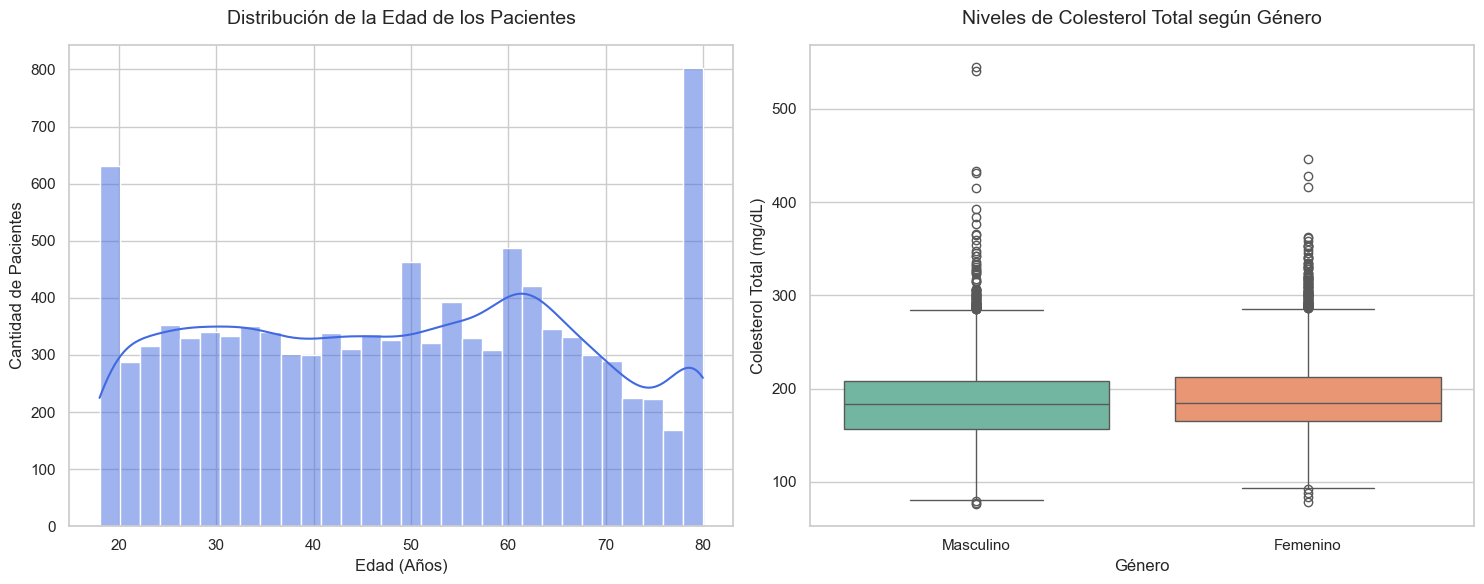

In [26]:
# Importar las librerías gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual (para que se vean profesionales)
sns.set_theme(style="whitegrid")

# Crear un "lienzo" con espacio para 2 gráficos juntos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---------------------------------------------------------
# Gráfico 1: Distribución de la Edad (Histograma)
# ---------------------------------------------------------
sns.histplot(data=df_salud, x='Edad', bins=30, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Distribución de la Edad de los Pacientes', fontsize=14, pad=15)
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Cantidad de Pacientes')

# ---------------------------------------------------------
# Gráfico 2: Género vs Colesterol Total (Boxplot)
# ---------------------------------------------------------
sns.boxplot(data=df_salud, x='Genero', y='Colesterol_Total', palette='Set2', ax=axes[1])
axes[1].set_title('Niveles de Colesterol Total según Género', fontsize=14, pad=15)
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Colesterol Total (mg/dL)')

# Ajustar el diseño y mostrar
plt.tight_layout()
plt.show()

In [27]:
# Verificar el rango de edad y el total de pacientes que logramos consolidar
print(f"Edad mínima: {df_salud['Edad'].min()} años")
print(f"Edad máxima: {df_salud['Edad'].max()} años")
print(f"Total de registros: {df_salud.shape[0]} pacientes")

Edad mínima: 18.0 años
Edad máxima: 80.0 años
Total de registros: 10601 pacientes


In [29]:
# Como no la incluiste en df_salud, vamos a buscarla en df_master o df_adultos
if 'df_adultos' in locals() and 'SDDSRVYR' in df_adultos.columns:
    print("📊 Ciclos activos en df_adultos:")
    print(df_adultos['SDDSRVYR'].value_counts())
elif 'df_master' in locals() and 'SDDSRVYR' in df_master.columns:
    print("📊 Ciclos activos en df_master:")
    print(df_master['SDDSRVYR'].value_counts())
else:
    print("❌ No se encontró la columna original. Las columnas actuales son:")
    print(df_salud.columns.tolist())

📊 Ciclos activos en df_adultos:
SDDSRVYR
9.0     5735
10.0    5533
Name: count, dtype: int64
